In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from pysheds.grid import Grid
import mplleaflet
# %matplotlib inline

In [2]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

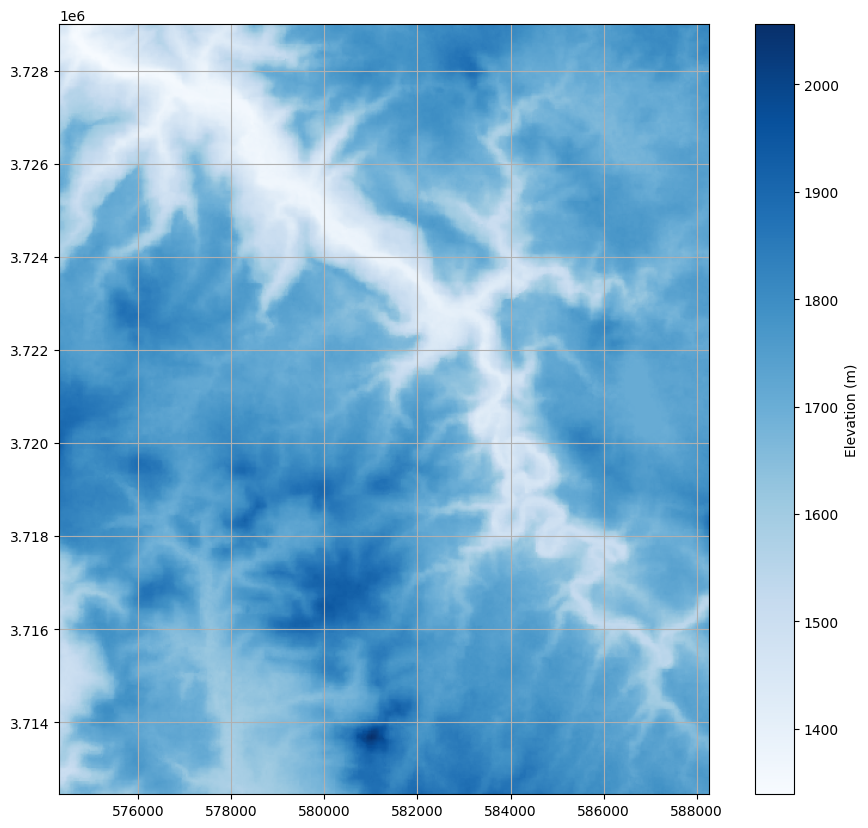

In [3]:
grid = Grid.from_raster('./assets/rst/clippedDem_12N.tif', data_name='dem')
dem = grid.read_raster('./assets/rst/clippedDem_12N.tif')
def plotFigure(data, label, cmap='Blues'):
    plt.figure(figsize=(12,10))
    plt.imshow(data, extent=grid.extent, cmap=cmap)
    plt.colorbar(label=label)
    plt.grid()
plotFigure(dem, 'Elevation (m)')

In [4]:
from urllib.request import urlretrieve
from os.path import basename

url = "https://tubcloud.tu-berlin.de/s/ZPiZjX3Nzc6R6RX/download/output_COP30.tif"
urlretrieve(url, basename(url))

('output_COP30.tif', <http.client.HTTPMessage at 0x7f49ae717fb0>)

I ""fixed"" it by commenting the faulty lines in sview.py (~L84):
```python
# try:
#   assert np.can_cast(viewfinder.nodata.dtype, obj.dtype, casting='safe')
# except:
#   raise TypeError('nodata value not representable in dtype of array.')
```

/home/juanguerrero09/dev/dampy/.venv/lib/python3.12/site-packages/pysheds/io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')
/home/juanguerrero09/dev/dampy/.venv/lib/python3.12/site-packages/pysheds/io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')


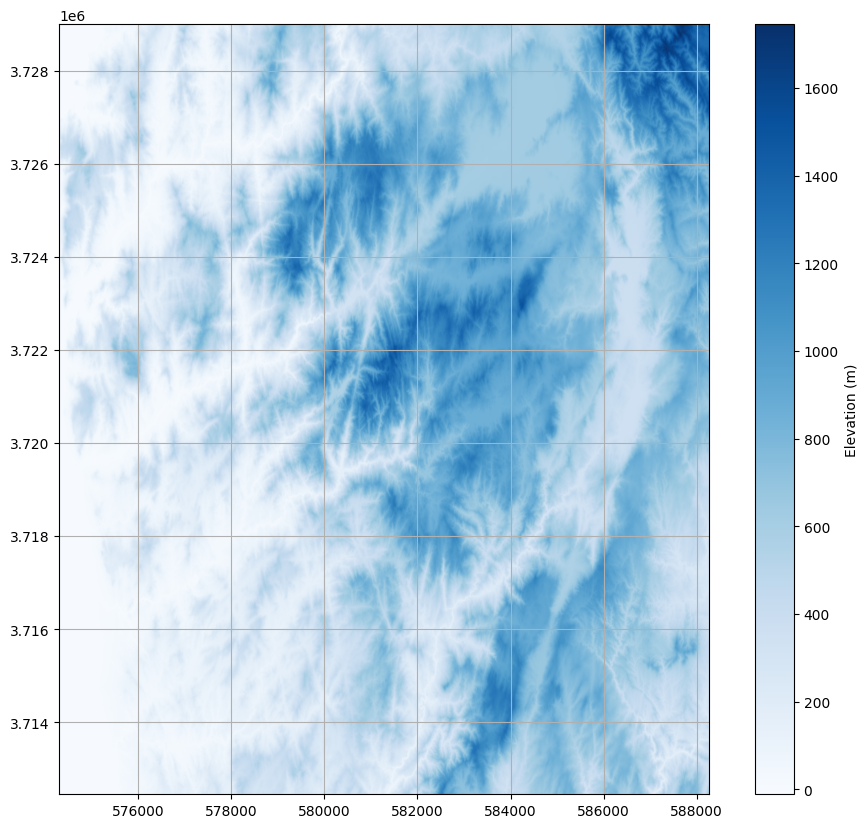

In [5]:
grid2 = Grid.from_raster('./output_COP30.tif', data_name='dem')
dem2 = grid.read_raster('./output_COP30.tif')
def plotFigure(data, label, cmap='Blues'):
    plt.figure(figsize=(12,10))
    plt.imshow(data, extent=grid.extent, cmap=cmap)
    plt.colorbar(label=label)
    plt.grid()
plotFigure(dem2, 'Elevation (m)')



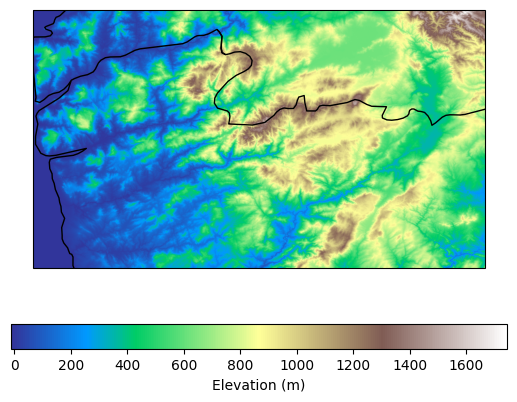

In [6]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
plt.imshow(dem2, extent=grid2.extent, cmap="terrain")
plt.colorbar(label="Elevation (m)", orientation="horizontal")
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

In [7]:
pit_filled_dem = grid.fill_pits(dem)
flooded_dem = grid.fill_depressions(pit_filled_dem)
conditioned_dem = grid.resolve_flats(flooded_dem)

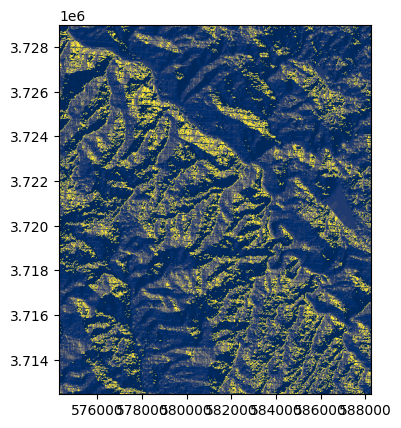

In [8]:
flowdir = grid.flowdir(conditioned_dem)
np.unique(flowdir)
plt.imshow(flowdir, extent=grid.extent, cmap="cividis")

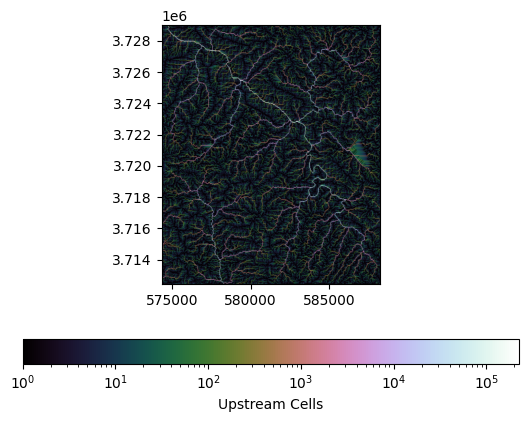

In [9]:
acc = grid.accumulation(flowdir)
fig, ax = plt.subplots()
im = ax.imshow(
    acc,
    extent=grid.extent,
    cmap="cubehelix",
    norm=LogNorm(1, acc.max()),
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Upstream Cells", orientation="horizontal")

In [17]:
x, y = 0, 0
x_snap, y_snap = grid.snap_to_mask(acc > 5000, (x, y))
print(f"Snapped coordinates: {x_snap}, {y_snap}")
catch = grid.catchment(x=x_snap, y=y_snap, fdir=flowdir, xytype="coordinate")

Snapped coordinates: 578025.6978970902, 3717246.1898394064


Snapped coordinates: 578230.8987555037, 3712484.2016854486

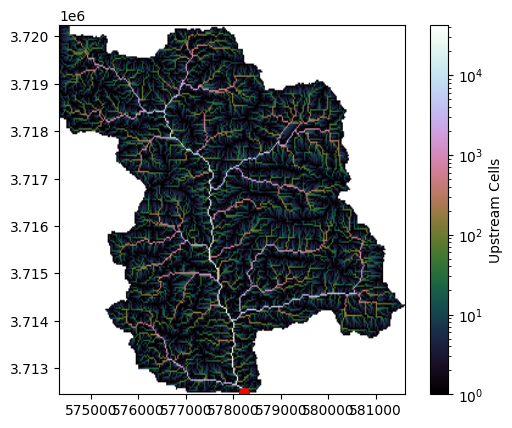

In [11]:
grid.clip_to(catch)
clipped_catch = grid.view(catch)
clipped_accumulated_flow = grid.accumulation(flowdir)
fig, ax = plt.subplots()
im = ax.imshow(
    np.where(clipped_catch, clipped_accumulated_flow, np.nan),
    extent=grid.extent,
    cmap="cubehelix",
    norm=LogNorm(1, clipped_accumulated_flow.max()),
    interpolation="bilinear",
)
plt.colorbar(
    im,
    ax=ax,
    label="Upstream Cells",
)
plt.scatter([x_snap], [y_snap], c="r", s=50)

Snapped coordinates: 578025.6978970902, 3717246.189839406


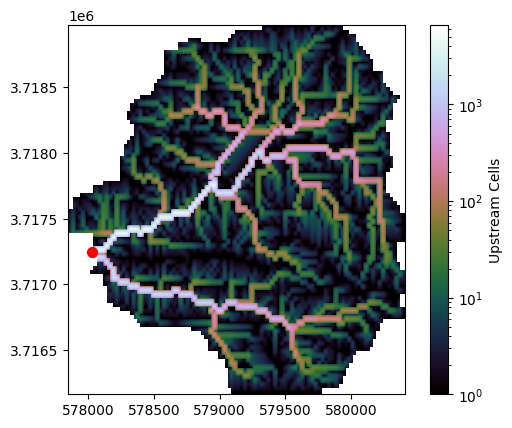

In [16]:
x, y = -7.954, 41.47
x_snap, y_snap = grid.snap_to_mask(acc > 5000, (x, y))
print(f"Snapped coordinates: {x_snap}, {y_snap}")
catch = grid.catchment(x=x_snap, y=y_snap, fdir=flowdir, xytype="coordinate")

grid.clip_to(catch)
clipped_catch = grid.view(catch)
clipped_accumulated_flow = grid.accumulation(flowdir)
fig, ax = plt.subplots()
im = ax.imshow(
    np.where(clipped_catch, clipped_accumulated_flow, np.nan),
    extent=grid.extent,
    cmap="cubehelix",
    norm=LogNorm(1, clipped_accumulated_flow.max()),
    interpolation="bilinear",
)
plt.colorbar(
    im,
    ax=ax,
    label="Upstream Cells",
)
plt.scatter([x_snap], [y_snap], c="r", s=50)

In [20]:
# Specify pour point
x, y = 3.8095, 43.5588
 
# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 5000, (x, y)) 
catch = grid.catchment(x=x_snap, y=y_snap, fdir=flowdir, xytype='coordinate')
masked_acc = np.ma.masked_array(acc, catch==False)

MaskError: Mask and data not compatible: data size is 291040, mask size is 9100.